# Setup

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parents[1]
sys.path.append(str(PROJECT_ROOT))

print("Added to PYTHONPATH:", PROJECT_ROOT)

Added to PYTHONPATH: c:\Users\yfess\Desktop\timeseries-thesis


In [2]:
from dotenv import load_dotenv
import os

env_file = PROJECT_ROOT / ".env"
print(env_file.exists())
load_dotenv(env_file)
print("Loaded env file:", env_file)

True
Loaded env file: c:\Users\yfess\Desktop\timeseries-thesis\.env


In [4]:
from src.common.config import load_config
from src.common.logger import get_logger
from src.databases.benchmark_db.config import get_postgres_config
from src.databases.benchmark_db.benchmark_db import BenchmarkDB

benchmarkdb_config_file_path = PROJECT_ROOT / "configs/config-benchmarkdb.yml"
benchmarkdb_config_dict = load_config(benchmarkdb_config_file_path)

logger = get_logger("benchmark_db", benchmarkdb_config_dict["general"]["log_file"])
benchmarkdb_config = get_postgres_config(benchmarkdb_config_dict["database"])
benchmarkdb_repo = BenchmarkDB(benchmarkdb_config, logger)

try:
    benchmarkdb_repo.connect()
    print("Connected to BenchmarkDB successfully.")
except Exception as e:
    print("Failed to connect to BenchmarkDB:", e)

Connected to BenchmarkDB successfully.


# Load Results

In [5]:
read_aggregate_ALL = benchmarkdb_repo.get_all_read_aggregate_benchmark_results()
len(read_aggregate_ALL)

360

In [6]:
one_r = read_aggregate_ALL[0]
print(one_r.to_dict())

{'id': 1, 'benchmark_name': 'read.aggregation', 'database_system': 'influxdb', 'database_version': '2.7', 'parameter': 'sea_water_temperature', 'range_window': '1_day', 'start_time': '2015-03-10T00:00:00+00:00', 'end_time': '2015-03-11T00:00:00+00:00', 'avg_value': None, 'min_value': None, 'max_value': None, 'row_count': None, 'elapsed_time_seconds': 0.018304747, 'elapsed_time_ns': 18304747, 'created_at': '2026-08-15T11:41:14.157935+00:00'}


# Partition & Colors

In [7]:
from collections import defaultdict

db_results = defaultdict(list)
for r in read_aggregate_ALL:
    db_results[r.database_system].append(r)

db_systems = sorted(db_results.keys())
db_systems

['influxdb', 'mongodb', 'timescaledb']

In [8]:
DB_COLOR_MAP = {
    'mongodb':     '#00ED64',
    'influxdb':    '#F18F13',
    'timescaledb': '#0064FF',
    'questdb':     '#FF5733',
}
DB_COLORS = ['#00ED64', '#F18F13', '#0064FF', '#FF5733', '#A855F7', '#EC4899']

db_color = {
    db: DB_COLOR_MAP.get(db, DB_COLORS[i % len(DB_COLORS)])
    for i, db in enumerate(db_systems)
}
db_color

{'influxdb': '#F18F13', 'mongodb': '#00ED64', 'timescaledb': '#0064FF'}

# DataFrame

In [9]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

rows = []
for db in db_systems:
    for r in db_results[db]:
        rows.append({
            'database_system': db,
            'parameter': r.parameter,
            'range_window': r.range_window,
            'avg_value': r.avg_value,
            'min_value': r.min_value,
            'max_value': r.max_value,
            'row_count': r.row_count,
            'elapsed_ns': r.elapsed_time_ns,
            'elapsed_ms': r.elapsed_time_ns / 1_000_000,
        })

df = pd.DataFrame(rows)
df.head()

,database_system,parameter,range_window,avg_value,min_value,max_value,row_count,elapsed_ns,elapsed_ms
0,influxdb,sea_water_temperature,1_day,NaN,NaN,NaN,NaN,18304747,18.304747
1,influxdb,sea_water_temperature,1_day,NaN,NaN,NaN,NaN,21189409,21.189409
2,influxdb,sea_water_temperature,1_day,NaN,NaN,NaN,NaN,16751435,16.751435
3,influxdb,sea_water_temperature,1_week,NaN,NaN,NaN,NaN,11188496,11.188496
4,influxdb,sea_water_temperature,1_week,NaN,NaN,NaN,NaN,11625175,11.625175


# Order Windows Logically

In [10]:
WINDOW_ORDER = [
    "1_day", "1_week", "1_month", "1_year",
    "3_years", "5_years", "10_years", "15_years_full",
]

df['range_window'] = pd.Categorical(df['range_window'], categories=WINDOW_ORDER, ordered=True)
windows_present = [w for w in WINDOW_ORDER if w in df['range_window'].unique()]
windows_present

['1_day',
 '1_week',
 '1_month',
 '1_year',
 '3_years',
 '5_years',
 '10_years',
 '15_years_full']

# Row Count Sanity Check — Confirm Boundary Consistency Across Databases

Given the InfluxDB inclusive/exclusive boundary issue found earlier, this check should now show matching counts across all three (245 for 1_day/temperature, etc.) — if not, the fix didn't fully propagate.

In [20]:
# row_count_pivot = df.pivot_table(
#     index='range_window',
#     columns='database_system',
#     values='row_count',
#     aggfunc='mean',
# ).reindex(windows_present)

# row_count_pivot = row_count_pivot[db_systems]
# row_count_pivot

# Avg Value Consistency Check

Confirms all three databases computed the same underlying aggregate (should match closely — small floating-point differences are fine, large ones indicate a filtering bug).

In [12]:
# avg_value_pivot = df.pivot_table(
#     index='range_window',
#     columns='database_system',
#     values='avg_value',
#     aggfunc='mean',
# ).reindex(windows_present)

# avg_value_pivot = avg_value_pivot[db_systems]
# avg_value_pivot.round(4)

# Raw Data Points + Mean Line — Latency vs. Window Size

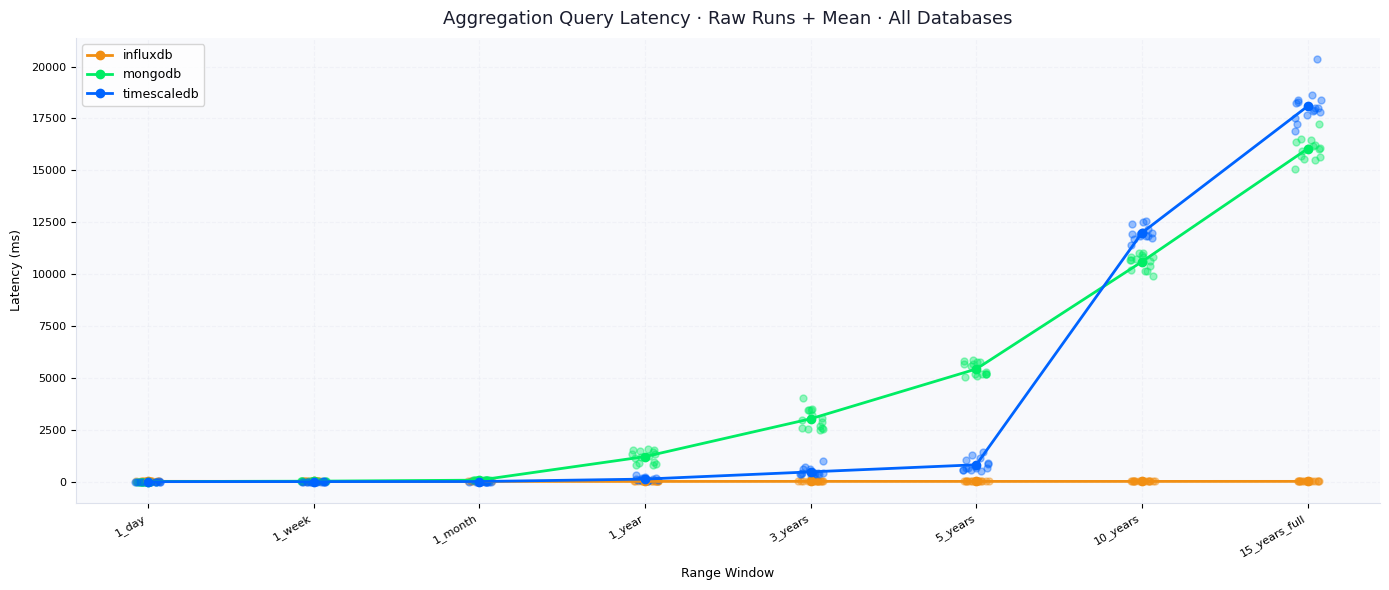

In [13]:
fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor('#ffffff')
ax.set_facecolor('#f8f9fc')

x_positions = {w: i for i, w in enumerate(windows_present)}

for db in db_systems:
    sub = df[df['database_system'] == db]

    for w in windows_present:
        vals = sub[sub['range_window'] == w]['elapsed_ms'].values
        if len(vals) == 0:
            continue
        jitter = np.random.uniform(-0.08, 0.08, size=len(vals))
        xs = np.full(len(vals), x_positions[w]) + jitter
        ax.scatter(xs, vals, color=db_color[db], alpha=0.4, s=25, zorder=2)

    means = [
        sub[sub['range_window'] == w]['elapsed_ms'].mean() if w in sub['range_window'].values else np.nan
        for w in windows_present
    ]
    ax.plot(range(len(windows_present)), means, marker='o', color=db_color[db], linewidth=2, label=db, zorder=3)

ax.set_xticks(range(len(windows_present)))
ax.set_xticklabels(windows_present, rotation=30, ha='right', fontsize=8)
ax.set_xlabel('Range Window', fontsize=9, labelpad=6)
ax.set_ylabel('Latency (ms)', fontsize=9, labelpad=6)
ax.set_title('Aggregation Query Latency · Raw Runs + Mean · All Databases', fontsize=13, pad=10, color='#1a1d2e')
ax.tick_params(axis='y', labelsize=8)
ax.spines[['top', 'right']].set_visible(False)
ax.spines[['left', 'bottom']].set_color('#dde1ec')
ax.legend(fontsize=9, loc='upper left')
ax.grid(True, alpha=0.4, color='#e4e7f0', linestyle='--', zorder=0)

plt.tight_layout()
plt.show()

# Same Chart, Log Scale

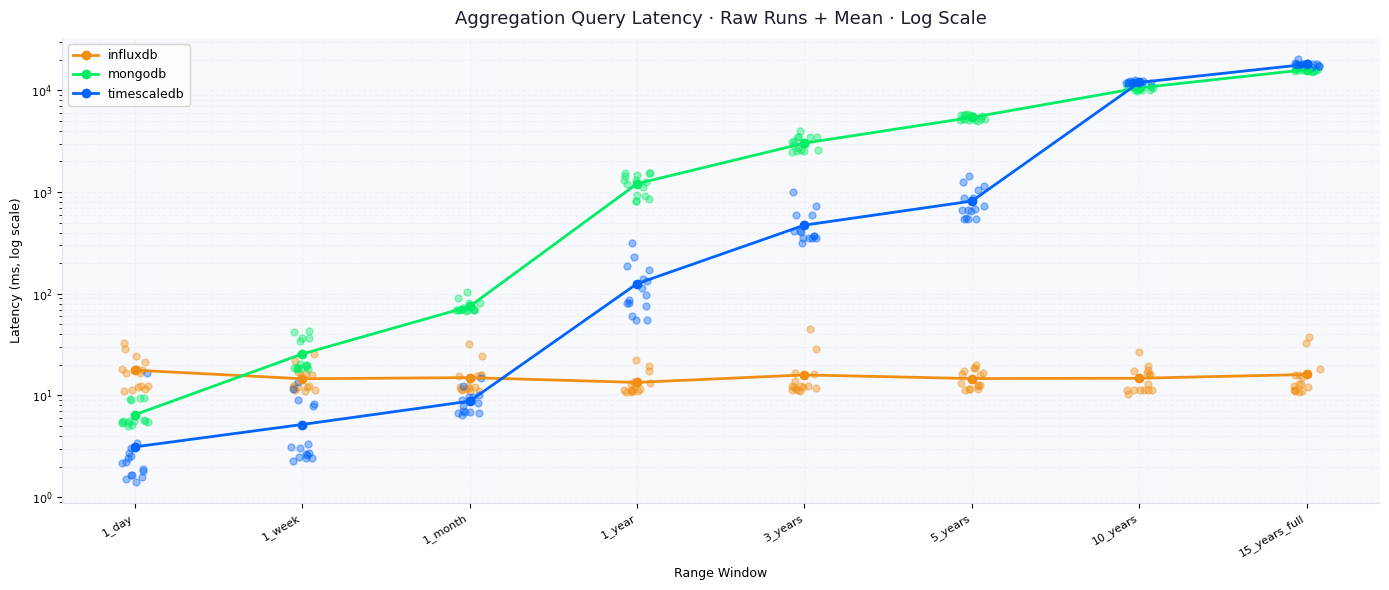

In [14]:
fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor('#ffffff')
ax.set_facecolor('#f8f9fc')

for db in db_systems:
    sub = df[df['database_system'] == db]

    for w in windows_present:
        vals = sub[sub['range_window'] == w]['elapsed_ms'].values
        if len(vals) == 0:
            continue
        jitter = np.random.uniform(-0.08, 0.08, size=len(vals))
        xs = np.full(len(vals), x_positions[w]) + jitter
        ax.scatter(xs, vals, color=db_color[db], alpha=0.4, s=25, zorder=2)

    means = [
        sub[sub['range_window'] == w]['elapsed_ms'].mean() if w in sub['range_window'].values else np.nan
        for w in windows_present
    ]
    ax.plot(range(len(windows_present)), means, marker='o', color=db_color[db], linewidth=2, label=db, zorder=3)

ax.set_yscale('log')
ax.set_xticks(range(len(windows_present)))
ax.set_xticklabels(windows_present, rotation=30, ha='right', fontsize=8)
ax.set_xlabel('Range Window', fontsize=9, labelpad=6)
ax.set_ylabel('Latency (ms, log scale)', fontsize=9, labelpad=6)
ax.set_title('Aggregation Query Latency · Raw Runs + Mean · Log Scale', fontsize=13, pad=10, color='#1a1d2e')
ax.tick_params(axis='y', labelsize=8)
ax.spines[['top', 'right']].set_visible(False)
ax.spines[['left', 'bottom']].set_color('#dde1ec')
ax.legend(fontsize=9, loc='upper left')
ax.grid(True, which='both', alpha=0.4, color='#e4e7f0', linestyle='--', zorder=0)

plt.tight_layout()
plt.show()

# Latency vs. Row Count Scanned (Scatter)

Shows whether aggregation cost scales with data volume, or is dominated by per-query overhead regardless of size — often reveals very different scaling behavior between server-side (Timescale/Influx) and unwind-based (Mongo) aggregation.

In [21]:
# fig, ax = plt.subplots(figsize=(10, 7))
# fig.patch.set_facecolor('#ffffff')
# ax.set_facecolor('#f8f9fc')

# for db in db_systems:
#     sub = df[df['database_system'] == db]
#     ax.scatter(sub['row_count'], sub['elapsed_ms'], color=db_color[db], alpha=0.6, s=40, label=db, zorder=3)

# ax.set_xscale('log')
# ax.set_yscale('log')
# ax.set_xlabel('Rows Aggregated (log scale)', fontsize=9, labelpad=6)
# ax.set_ylabel('Latency (ms, log scale)', fontsize=9, labelpad=6)
# ax.set_title('Aggregation Latency vs. Row Count', fontsize=13, pad=10, color='#1a1d2e')
# ax.spines[['top', 'right']].set_visible(False)
# ax.spines[['left', 'bottom']].set_color('#dde1ec')
# ax.legend(fontsize=9, loc='upper left')
# ax.grid(True, which='both', alpha=0.4, color='#e4e7f0', linestyle='--', zorder=0)

# plt.tight_layout()
# plt.show()

# Summary Table

In [16]:
summary_pivot = df.pivot_table(
    index='range_window',
    columns='database_system',
    values='elapsed_ms',
    aggfunc='mean',
).reindex(windows_present)

summary_pivot = summary_pivot[db_systems]
summary_pivot.round(3)

database_system,influxdb,mongodb,timescaledb
range_window,,,
1_day,17.725,6.451,3.118
1_week,14.590,25.565,5.178
1_month,14.978,74.977,8.779
1_year,13.435,1208.234,125.637
3_years,15.917,3030.165,473.422
5_years,14.656,5429.318,816.172
10_years,14.762,10598.105,11989.049
15_years_full,16.071,16038.390,18085.161
